In [228]:
import os 
import pandas as pd
from sklearn.preprocessing import RobustScaler
import numpy as np
import ast
from pathlib import Path


In [ ]:
# Get the current directory
current_directory = os.getcwd()

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_training_data.csv"
df = pd.read_csv(file, header=0)
df

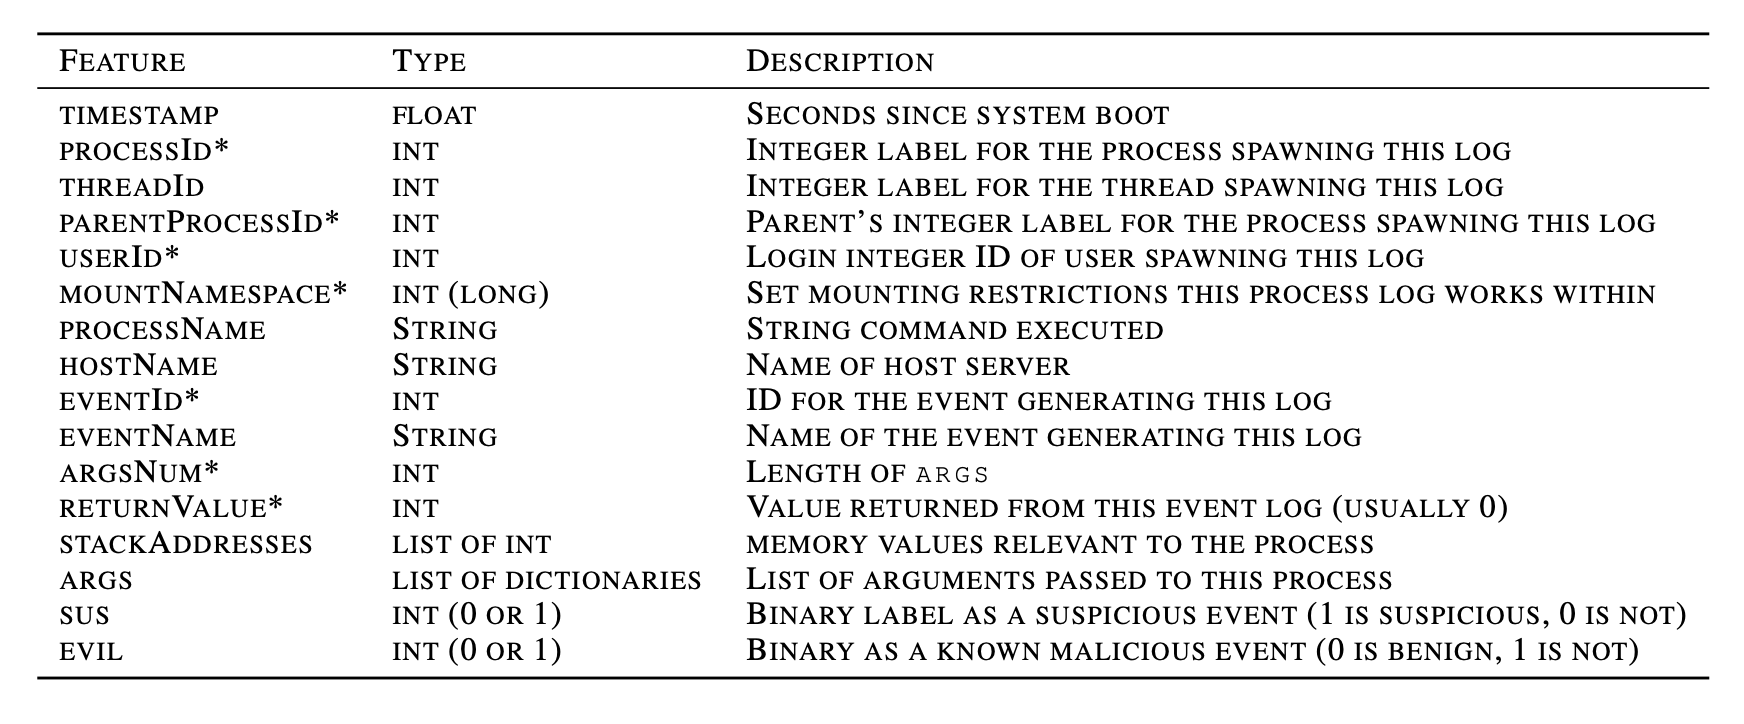


#### 1. Prepare process and user identifiers columns

In [212]:
# todo: convert ['processId','threadId','parentProcessId','userId','mountNamespace','eventId'] to categorical features

# processId: Process IDs 0, 1, and 2 are meaningful since
# these are always values used by the OS, but otherwise a
# random number is assigned to the process upon creation. We
# recommend replacing processId with a binary variable
# indicating whether or not processID is 0, 1, or 2.

# threadId: While this value did not appear useful in our
# analysis, it might suggest how to link process calls if obfus-
# cated in the system. No conversion is recommended at this
# time.

# parentProcessId: Same as processId, the same
# mapping to a binary variable should suffice.

# userId: The default in Linux systems is to assign OS
# activity to some number below 1000 (typically 0). As users
# login, they are assigned IDs starting at 1000, incrementally.
# This can be altered by a user, but none of the current logs
# gave evidence an attacker did this. We used a binary variable
# to indicate userId < 1000 or userId ≥1000. Alterna-
# tively, one could use an ordinal mapping that buckets all
# userId < 1000 at zero and then increment upwards for
# each new user. Also, no more than four logins were viewed
# per host in our current datasets.

In [213]:
# Adding frequency features for multiple columns
for col in ['processId','threadId','parentProcessId','userId','mountNamespace','eventId']:
    df[col + "_freq"] = df.groupby(["hostName", col])[col].transform("size")

# exam the data
df[["hostName", "processId", "processId_freq"]].sort_values(by=["hostName", "processId"]).drop_duplicates()

,hostName,processId,processId_freq
274,ip-10-100-1-120,1,2890
6650,ip-10-100-1-120,7,1
43211,ip-10-100-1-120,8,1
31321,ip-10-100-1-120,80,1
5390,ip-10-100-1-120,93,1
...,...,...,...
669301,ubuntu,8120,419
669745,ubuntu,8121,5
669740,ubuntu,8122,5
669811,ubuntu,8289,88


In [214]:
df["userId_binary"]  = df["userId"].apply(lambda x: 1 if x < 1000 else 0)

#### 2. Transform stackAddresses column to numeric features

In [215]:
# convert stackAddresses from string to list of integers
df['stackAddresses'] = df['stackAddresses'].apply(lambda x: [int(i) for i in x.strip('[]').strip(' ').split(',') if i])


In [216]:
# calculate the length of a stackAddresses
df['stackAddresses_len'] = df['stackAddresses'].apply(len)
df['stackAddresses_len'].describe()

count    763144.000000
mean          0.716571
std           1.564038
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          20.000000
Name: stackAddresses_len, dtype: float64

In [217]:
# normal stacks are often continuous, while abnormal stacks may have large jumps.
# calculate the standard deviation of the differences between consecutive stack addresses
def stack_jump_std(stack):
    if len(stack) < 2:
        return 0
    diffs = [abs(stack[i] - stack[i+1]) for i in range(len(stack)-1)]
    return np.std(diffs)
df['stackAddresses_jump_std'] = df['stackAddresses'].apply(stack_jump_std)
df['stackAddresses_jump_std'].describe()

count    7.631440e+05
mean     1.866341e+17
std      7.614632e+17
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.846849e+18
Name: stackAddresses_jump_std, dtype: float64

In [218]:
# For normal function call, the stackAddresses should be highly diverse.
# malicious or abnormal behavior, it often manipulates and uses stack addresses.
df['stackAddresses_unique_ratio'] = df['stackAddresses'].apply(lambda x: len(set(x)) / max(len(x), 1))
df['stackAddresses_unique_ratio'].describe()

count    763144.000000
mean          0.316957
std           0.465113
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: stackAddresses_unique_ratio, dtype: float64

#### 3. add a new feature indicating whether a process end with an error.

In [219]:
df["returnValue_is_error"] = (df["returnValue"] == -1).astype(int)

#### 4. TODO: process arg column.

In [220]:
# args: There are many options in this variable list of dictio-
# naries. For simplicity, we refrain from utilising any of these
# values. However, more features can and should be created
# for future work.

def argument_parse(args_str):
    return ast.literal_eval(args_str)

df['args'] = df['args'].apply(argument_parse)

df['args_has_path'] = df['args'].apply(lambda x: int(any('pathname' in d['name'] for d in x)))
df[['args_has_path', 'args']].head(10)

,args_has_path,args
0,0,"[{'name': 'option', 'type': 'int', 'value': 'P..."
1,0,"[{'name': 'fd', 'type': 'int', 'value': 19}]"
2,0,[]
3,1,"[{'name': 'pathname', 'type': 'const char*', '..."
4,1,"[{'name': 'pathname', 'type': 'const char*', '..."
5,1,"[{'name': 'dirfd', 'type': 'int', 'value': -10..."
6,0,"[{'name': 'fd', 'type': 'int', 'value': 3}, {'..."
7,0,"[{'name': 'fd', 'type': 'int', 'value': 3}]"
8,1,"[{'name': 'pathname', 'type': 'const char*', '..."
9,1,"[{'name': 'dirfd', 'type': 'int', 'value': -10..."


#### 4. process mountNamespace column.

In [221]:
# mountNamespace: This field is somewhat consistent
# across our hosts and determines the access a certain pro-
# cess has to various mount points. The most common value
# for this feature is 4026531840 or 0xF0000000, which is
# for the mnt/ directory where all manually mounted points
# are linked. It is noted that all logs with userId ≥1000
# had a mountNamespace of 4026531840, while some OS
# userId traffic used different mountNamespace values.
# We converted this feature into a binary mappin

def mount_ns_binary(ns):
    return int(ns == 4026531840)

df['mountNamespace_binary'] = df['mountNamespace'].apply(mount_ns_binary)

#### 5. scale the numeric features

In [222]:
scaler = RobustScaler()
df[["stackAddresses_len", "stackAddresses_jump_std","argsNum"]] = scaler.fit_transform(df[["stackAddresses_len", "stackAddresses_jump_std","argsNum"]])
df.head()


,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,...,userId_freq,mountNamespace_freq,eventId_freq,userId_binary,stackAddresses_len,stackAddresses_jump_std,stackAddresses_unique_ratio,returnValue_is_error,args_has_path,mountNamespace_binary
0,1809.495787,381,7337,1,100,4026532231,close,ip-10-100-1-120,157,prctl,...,188,188,169,1,2.0,0.0,1.0,0,0,0
1,1809.495832,381,7337,1,100,4026532231,close,ip-10-100-1-120,3,close,...,188,188,26651,1,1.0,0.0,1.0,0,0,0
2,1809.495921,381,7337,1,100,4026532231,close,ip-10-100-1-120,1010,sched_process_exit,...,188,188,154,1,0.0,0.0,0.0,0,0,0
3,1894.139651,7347,7347,7341,0,4026531840,sh,ip-10-100-1-120,21,access,...,94482,94865,192,1,0.0,0.0,0.0,0,1,1
4,1894.142127,7347,7347,7341,0,4026531840,sh,ip-10-100-1-120,1005,security_file_open,...,94482,94865,24073,1,2.0,0.0,1.0,0,1,1


In [223]:
df.columns

Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil',
       'processId_freq', 'threadId_freq', 'parentProcessId_freq',
       'userId_freq', 'mountNamespace_freq', 'eventId_freq', 'userId_binary',
       'stackAddresses_len', 'stackAddresses_jump_std',
       'stackAddresses_unique_ratio', 'returnValue_is_error', 'args_has_path',
       'mountNamespace_binary'],
      dtype='object')

In [ ]:
folder_path = Path(f"{current_directory}/datasets/processed/")

# Create the directory(ies).
# parents=True ensures missing parent directories are created.
# exist_ok=True prevents an error if the directory already exists.
folder_path.mkdir(parents=True, exist_ok=True)

print(f"Folder structure '{folder_path}' created successfully.")

Folder structure '/Users/cheesecake/Github/beth-dataset-anamoly-detection/datasets/processed' created successfully.


In [227]:
df[['sus', 'evil',
       'processId_freq', 'threadId_freq', 'parentProcessId_freq',
       'userId_freq', 'mountNamespace_freq', 'eventId_freq', 'userId_binary',
       'stackAddresses_len', 'stackAddresses_jump_std',
       'stackAddresses_unique_ratio', 'returnValue_is_error', 'args_has_path',
       'mountNamespace_binary']].to_csv(f"{current_directory}/datasets/processed/processed_training_data.csv", index=False)